In [334]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [335]:
from sklearn.datasets import make_blobs

In [336]:
X,y=make_blobs(n_samples=1000,n_features=2,centers=3)

In [337]:
X

array([[ 8.50914469, -5.86838633],
       [-1.15793093, -5.62120204],
       [ 8.50200894, -6.36606582],
       ...,
       [ 7.82111794, -7.79791136],
       [ 6.48878634,  4.23207331],
       [ 7.31199975,  5.25341657]], shape=(1000, 2))

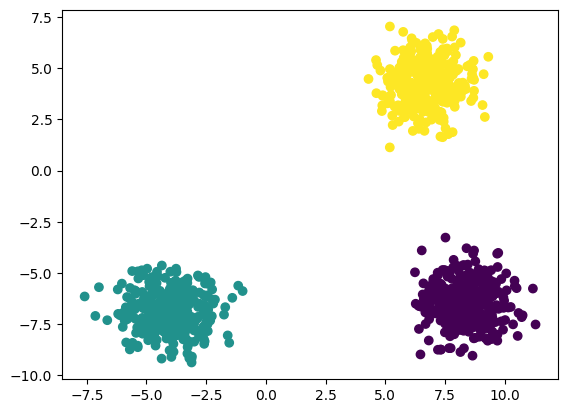

In [338]:
plt.scatter(x=X[:,0],y=X[:,1],c=y)

In [339]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.33,random_state=42)

In [340]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
xtrain=ss.fit_transform(xtrain)
xtest=ss.transform(xtest)

In [341]:
from sklearn.cluster import KMeans

### Elbow method to find k value

In [342]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(xtrain)
    wcss.append(kmeans.inertia_)

In [343]:
wcss

[1340.0000000000005,
 595.2198988649533,
 44.17957231471122,
 38.39749896797778,
 32.996727776154955,
 29.327687704271195,
 24.450665090614287,
 21.890388560024892,
 20.29215652872865,
 17.588862660292495]

Text(0.5, 0, 'k-value')

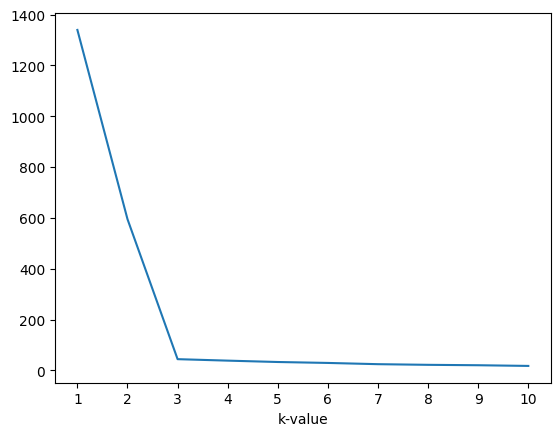

In [344]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('k-value')

In [345]:
kmeans=KMeans(n_clusters=2,init='k-means++')
kmeans.fit_predict(xtrain)
y_pred=kmeans.predict(xtest)

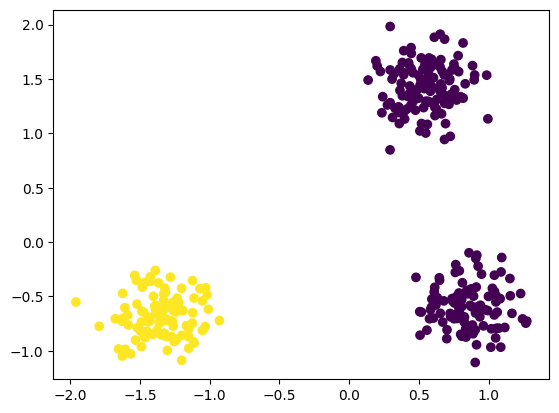

In [346]:
plt.scatter(x=xtest[:,0],y=xtest[:,1],c=y_pred)

### Using kneelocator

In [347]:
from kneed import KneeLocator

In [348]:
k1=KneeLocator(range(1,11),wcss,direction='decreasing',curve='convex')

In [349]:
k1.elbow

np.int64(3)

### silhouette score to find k value

In [350]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_coef = []

for k in range(2, 11):   # ❗ start from 2
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(xtrain)
    
    score = silhouette_score(xtrain, kmeans.labels_)
    silhouette_coef.append(score)



In [351]:
silhouette_coef

[0.638866616982849,
 0.8455350683159035,
 0.6891849191361427,
 0.5262882368876759,
 0.33996022873392917,
 0.3478032101366802,
 0.3161079245823978,
 0.3360450619012004,
 0.3543610287674765]

Text(0.5, 0, 'k-value')

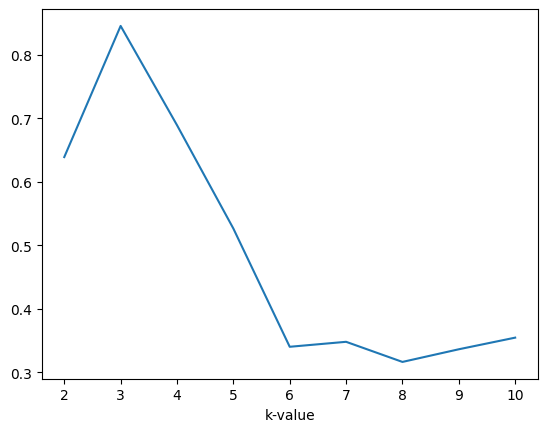

In [352]:
plt.plot(range(2,11),silhouette_coef)
plt.xticks(range(2,11))
plt.xlabel('k-value')